In [229]:
#import libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

In [230]:
#import data
df = pd.read_csv("jiji_housing_raw.csv")

**Data Inspection**

In [231]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               2000 non-null   str    
 1   property_size       1995 non-null   float64
 2   house_type          1984 non-null   str    
 3   bedrooms            1999 non-null   float64
 4   bathrooms           1999 non-null   float64
 5   furnishing          1999 non-null   str    
 6   region              2000 non-null   str    
 7   region_name         2000 non-null   str    
 8   region_parent_name  1995 non-null   str    
 9   is_boost            2000 non-null   str    
 10  price               2000 non-null   str    
dtypes: float64(3), str(8)
memory usage: 402.0 KB


In [232]:
df.shape

(2000, 11)

In [233]:
df.isnull().sum()

title                  0
property_size          5
house_type            16
bedrooms               1
bathrooms              1
furnishing             1
region                 0
region_name            0
region_parent_name     5
is_boost               0
price                  0
dtype: int64

In [234]:
df.head()

,title,property_size,house_type,bedrooms,bathrooms,furnishing,region,region_name,region_parent_name,is_boost,price
0,2bdrm Maisonette in Lekki Phase 1 for sale,185.0,Maisonette,2.0,2.0,unfurnished,"Lekki, Lekki Phase 1",Lekki Phase 1,Lekki,diamond,"₦ 350,000,000"
1,4bdrm Duplex in Thomas Estate for sale,300.0,Duplex,4.0,4.0,semi-furnished,"Ajah, Thomas Estate",Thomas Estate,Ajah,enterprise,"₦ 300,000,000"
2,"5bdrm Duplex in Lekki Palm City, Ado / Ajah fo...",300.0,Duplex,5.0,5.0,semi-furnished,"Ajah, Ado / Ajah",Ado / Ajah,Ajah,enterprise,"₦ 300,000,000"
3,"4bdrm Duplex in Golden Park Estate, Sangotedo ...",300.0,Duplex,4.0,4.0,semi-furnished,"Ajah, Sangotedo",Sangotedo,Ajah,enterprise,"₦ 275,000,000"
4,Mini Flat in Mende for sale,120.0,NaN,1.0,1.0,unfurnished,"Maryland, Mende",Mende,Maryland,vip_gold,"₦ 75,000,000"


**Data Cleaning**

In [235]:
#dropping null values
df = df.dropna()

In [236]:
#turning float columns to int
df["property_size"] = (
    df["property_size"]
    .astype(float)
    .astype(int)
)
df["bedrooms"] = (
    df["bedrooms"]
    .astype(float)
    .astype(int)
)
df["bathrooms"] = (
    df["bathrooms"]
    .astype(float)
    .astype(int)
)

In [237]:
#standardizing text in 'furnishing' and 'is_boost'
df["furnishing"] = (
    df["furnishing"]
    .str.strip()
    .str.title()
)
df["is_boost"] = (
    df["is_boost"]
    .str.strip()
    .str.title()
)

In [238]:
#changing price to float
df["price"] = (
    df["price"]
    .astype(str)
    .replace('[₦,]', "", regex=True)
    .astype(float)
)


In [239]:
#checking outliers in price
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

detect_outlier = (
    (df["price"] < lower_bound) | (df["price"] > upper_bound)
)
print(detect_outlier.sum())

186


In [240]:
#dropping outliers
df = df.drop(df[detect_outlier].index)

In [241]:
df = df.rename(columns={
    "property_size": "property_size(sqm)"
})

In [242]:
df["region_parent_name"].unique()

<ArrowStringArray>
[          'Lekki',            'Ajah',            'Jiwa',          'Magodo',
     'Abuja (FCT)',           'Ibeju',     'Lagos State',        'Gwarinpa',
             'Ojo',       'Imo State',  'Nasarawa State',       'Oyo State',
      'Ondo State',       'Edo State',           'Ikeja',      'Ogun State',
    'Rivers State',   'Port-Harcourt',         'Gbagada',        'Maryland',
         'Ilupeju',         'Katampe',           'Ojodu',            'Yaba',
        'Alimosho',            'Ogba',          'Ibadan',    'Amuwo-Odofin',
         'Ikorodu',           'Ipaja',    'Ifako-Ijaiye', 'Victoria Island',
          'Sagamu',         'Shomolu',          'Gwagwa',        'Surulere',
           'Ogudu',      'Egbe/Idimu',   'Ikotun/Igando',           'Agege',
          'Egbeda',     'Delta State',           'Isolo',          'Afijio',
      'Abia State',    'Apo District',     'Enugu State',         'Garki 1',
  'Lugbe District',           'Ikoyi',     'Benue State',

In [243]:
master_mapping = {
    # --- LAGOS ISLAND ---
    'Lekki': 'Lagos Island', 'Ikoyi': 'Lagos Island', 'Victoria Island': 'Lagos Island', 'Ajah': 'Lagos Island', 
    'Ibeju': 'Lagos Island', 'Osapa London': 'Lagos Island', 'Chevron': 'Lagos Island', 'Ikate': 'Lagos Island', 
    'Lekki Phase 1': 'Lagos Island', 'Lekki Phase 2': 'Lagos Island', 'Lekki Expressway': 'Lagos Island', 
    'Oniru': 'Lagos Island', 'Lafiaji': 'Lagos Island', 'Ologolo': 'Lagos Island', 'Agungi': 'Lagos Island', 
    'Orchid': 'Lagos Island', 'Ikota': 'Lagos Island', 'VGC': 'Lagos Island', 'Banana Island': 'Lagos Island', 
    'Elegushi': 'Lagos Island', 'Idado': 'Lagos Island', 'Sangotedo': 'Lagos Island', 'Abijo': 'Lagos Island', 
    'Olokonla': 'Lagos Island', 'Lagos Island (Eko)': 'Lagos Island', 'Victoria Island Extension': 'Lagos Island',
    'Ikoyi S.W': 'Lagos Island', 'Old Ikoyi': 'Lagos Island', 'Ikoyi South West': 'Lagos Island', 
    'Northern Foreshore': 'Lagos Island', 'Chevron Drive': 'Lagos Island', 'Makogi Estate': 'Lagos Island',
    'Cowrie Creek': 'Lagos Island', 'Discovery Park': 'Lagos Island', 'Hi-Life Estate': 'Lagos Island',
    'Dpk Estate': 'Lagos Island', 'De Man Pr': 'Lagos Island', 'Karimu Kotun': 'Lagos Island',
    'Milverton': 'Lagos Island', 'Secured Are': 'Lagos Island', 'Lagos Island / Lagos Island': 'Lagos Island',

    # --- LAGOS MAINLAND ---
    'Yaba': 'Lagos Mainland', 'Ikeja': 'Lagos Mainland', 'Surulere': 'Lagos Mainland', 'Agege': 'Lagos Mainland', 
    'Ojodu': 'Lagos Mainland', 'Ikorodu': 'Lagos Mainland', 'Ifako-Ijaiye': 'Lagos Mainland', 'Kosofe': 'Lagos Mainland', 
    'Amuwo-Odofin': 'Lagos Mainland', 'Ojo': 'Lagos Mainland', 'Egbe/Idimu': 'Lagos Mainland', 'Ejigbo': 'Lagos Mainland', 
    'Gbagada': 'Lagos Mainland', 'Magodo': 'Lagos Mainland', 'Ilupeju': 'Lagos Mainland', 'Maryland': 'Lagos Mainland', 
    'Abule Egba': 'Lagos Mainland', 'Alakuko': 'Lagos Mainland', 'Ipaja': 'Lagos Mainland', 'Iyana Ipaja': 'Lagos Mainland', 
    'Baruwa': 'Lagos Mainland', 'Ketu-Ikosi': 'Lagos Mainland', 'Iwaya': 'Lagos Mainland', 'Alagomeji': 'Lagos Mainland', 
    'Fadeyi': 'Lagos Mainland', 'Jibowu': 'Lagos Mainland', 'Ogba': 'Lagos Mainland', 'Oke-Ira / Ogba': 'Lagos Mainland', 
    'Opebi': 'Lagos Mainland', 'Omole Phase 1': 'Lagos Mainland', 'Omole Phase 2': 'Lagos Mainland', 
    'Adeniyi Jones': 'Lagos Mainland', 'Igando / Ikotun/Igando': 'Lagos Mainland', 'Ikotun / Ikotun/Igando': 'Lagos Mainland', 
    'Ibeshe / Amuwo-Odofin': 'Lagos Mainland', 'Festac': 'Lagos Mainland', 'Oshodi': 'Lagos Mainland', 'Isolo': 'Lagos Mainland', 
    'Mushin': 'Lagos Mainland', 'Apapa': 'Lagos Mainland', 'Ebute Metta': 'Lagos Mainland', 'Mende': 'Lagos Mainland', 
    'Ogudu': 'Lagos Mainland', 'Ogudu GRA': 'Lagos Mainland', 'Ifako-Ogba': 'Lagos Mainland', 'Alimosho': 'Lagos Mainland',
    'Shomolu': 'Lagos Mainland', 'Lagos State': 'Lagos Mainland', 'Ikotun/Igando': 'Lagos Mainland',
    'Oko-Oba': 'Lagos Mainland', 'New Oko Oba': 'Lagos Mainland', 'Fagba': 'Lagos Mainland', 'Ago Palace': 'Lagos Mainland', 
    'Ajao Estate': 'Lagos Mainland', 'Oke-Afa': 'Lagos Mainland', 'Osolo Way': 'Lagos Mainland', 'Alaka Estate': 'Lagos Mainland', 
    'Eric Moore': 'Lagos Mainland', 'Western Avenue': 'Lagos Mainland', 'New Garage / Gbagada': 'Lagos Mainland', 
    'Ifako-Gbagada': 'Lagos Mainland', 'White House': 'Lagos Mainland', 'Diamond Estate': 'Lagos Mainland',
    'Unique Estate': 'Lagos Mainland', 'Peace Estate': 'Lagos Mainland', 'Adexson': 'Lagos Mainland',
    'Private Estate': 'Lagos Mainland', 'Secured Estate': 'Lagos Mainland', 'Secured Area': 'Lagos Mainland',
    'Private Property': 'Lagos Mainland', 'Market Square': 'Lagos Mainland', 'Ipaja / Ipaja': 'Lagos Mainland',
    'Ayobo': 'Lagos Mainland', 'Aboru Harmony Estate': 'Lagos Mainland',

    # --- ABUJA (FCT) ---
    'Gwarinpa': 'Abuja (FCT)', 'Wuse': 'Abuja (FCT)', 'Maitama': 'Abuja (FCT)', 'Asokoro': 'Abuja (FCT)', 
    'Jahi': 'Abuja (FCT)', 'Jabi': 'Abuja (FCT)', 'Wuye': 'Abuja (FCT)', 'Guzape': 'Abuja (FCT)', 'Lugbe': 'Abuja (FCT)', 
    'Kubwa': 'Abuja (FCT)', 'Mabushi': 'Abuja (FCT)', 'Utako': 'Abuja (FCT)', 'Durumi': 'Abuja (FCT)', 'Kado': 'Abuja (FCT)', 
    'Katampe': 'Abuja (FCT)', 'Apo': 'Abuja (FCT)', 'Garki': 'Abuja (FCT)', 'Idu Industrial': 'Abuja (FCT)', 
    'Lokogoma': 'Abuja (FCT)', 'Mbora': 'Abuja (FCT)', 'Sabon Lugbe': 'Abuja (FCT)', 'Galadimawa': 'Abuja (FCT)', 
    'Karmo': 'Abuja (FCT)', 'Gwagwa': 'Abuja (FCT)', 'Ushafa': 'Abuja (FCT)', 'Dawaki': 'Abuja (FCT)', 'Life Camp': 'Abuja (FCT)', 
    'Zone 3 / Wuse': 'Abuja (FCT)', 'Zone 1 / Wuse': 'Abuja (FCT)', 'Lugbe District': 'Abuja (FCT)', 'Guzape District': 'Abuja (FCT)', 
    'Garki 1': 'Abuja (FCT)', 'Apo District': 'Abuja (FCT)', 'Apo Resettlement': 'Abuja (FCT)', 'Katampe Extension': 'Abuja (FCT)', 
    'Kaura': 'Abuja (FCT)', 'Karshi': 'Abuja (FCT)', 'Jiwa': 'Abuja (FCT)', 'Idu': 'Abuja (FCT)', 'Bwari': 'Abuja (FCT)', 
    'Abuja (Fct)': 'Abuja (FCT)', 'Abuja (FCT)': 'Abuja (FCT)', 'Garki Area 8': 'Abuja (FCT)', 'Area 1': 'Abuja (FCT)',
    'Area 8': 'Abuja (FCT)', 'Zone B': 'Abuja (FCT)', 'Karsana': 'Abuja (FCT)', 'Fha': 'Abuja (FCT)',
    'River Park Estate': 'Abuja (FCT)', 'Planet Hills': 'Abuja (FCT)', 'Sea Man Estate': 'Abuja (FCT)',
    'Efab Queen Estate': 'Abuja (FCT)', 'Spring Meadow': 'Abuja (FCT)', 'Naf Valley Estate': 'Abuja (FCT)',

    # --- OTHER STATES (Mapping Cities/LGAs to States) ---
    'Ibadan': 'Oyo State', 'Agodi': 'Oyo State', 'Oluyole Estate': 'Oyo State', 'Bodija': 'Oyo State', 'Akobo': 'Oyo State', 
    'Jericho': 'Oyo State', 'Akala Express': 'Oyo State', 'Rind Road': 'Oyo State', 'Egbeda': 'Oyo State', 'Oyo State': 'Oyo State',
    'Benin City': 'Edo State', 'Ikpoba-Okha': 'Edo State', 'Edo State': 'Edo State',
    'Port-Harcourt': 'Rivers State', 'Obio-Akpor': 'Rivers State', 'Trans Amadi': 'Rivers State', 'Rumuahalu': 'Rivers State', 
    'Eneka': 'Rivers State', 'Choba': 'Rivers State', 'Uzoba': 'Rivers State', 'Rivers State': 'Rivers State',
    'Enugu': 'Enugu State', 'Thinkers Corner': 'Enugu State', 'Golf Annex': 'Enugu State', 'Centenary City': 'Enugu State', 
    'Transekulu New Gra': 'Enugu State', 'Enugu State': 'Enugu State',
    'Uyo': 'Akwa Ibom State', 'Akwa Ibom State': 'Akwa Ibom State', 'John Linus Road': 'Akwa Ibom State', 'Osongama Estate': 'Akwa Ibom State', 'Abak Road': 'Akwa Ibom State',
    'Kaduna': 'Kaduna State', 'Barnawa': 'Kaduna State', 'Kaduna State': 'Kaduna State', 'High Cost': 'Kaduna State', 'Narayi High Cost': 'Kaduna State',
    'Nasarawa-Kano': 'Kano State', 'Kano State': 'Kano State',
    'Owerri': 'Imo State', 'Imo State': 'Imo State',
    'Jos': 'Plateau State', 'Plateau State': 'Plateau State',
    'Ilorin': 'Kwara State', 'Ilorin South': 'Kwara State', 'Kwara State': 'Kwara State',
    'Dutse': 'Jigawa State', 'Jigawa State': 'Jigawa State',
    'Akure': 'Ondo State', 'Ondo State': 'Ondo State',
    'Ado-Odo/Ota': 'Ogun State', 'Obafemi-Owode': 'Ogun State', 'Pakuro': 'Ogun State', 'Ogun State': 'Ogun State',
    'Oshimili North': 'Delta State', 'Asaba': 'Delta State', 'Delta State': 'Delta State'
}

def standardize_region(row):
    region_name = str(row['region_name']).strip().title()
    current_parent = str(row['region_parent_name']).strip().title()
    
    # Check region_name first, then region_parent_name against the master dictionary
    if region_name in master_mapping:
        return master_mapping[region_name]
    elif current_parent in master_mapping:
        return master_mapping[current_parent]
    else:
        # If it's completely unknown, return NaN so we can drop it later
        return np.nan

# Apply standardization
df['region_parent_name'] = df.apply(standardize_region, axis=1)

In [244]:
df["region_parent_name"].unique()

<ArrowStringArray>
[  'Lagos Island',    'Abuja (FCT)', 'Lagos Mainland',      'Imo State',
              nan,      'Oyo State',     'Ondo State',      'Edo State',
     'Ogun State',   'Rivers State',    'Delta State',    'Enugu State',
   'Kaduna State']
Length: 13, dtype: str

In [245]:
df = df.dropna()

In [246]:
df.head()

,title,property_size(sqm),house_type,bedrooms,bathrooms,furnishing,region,region_name,region_parent_name,is_boost,price
0,2bdrm Maisonette in Lekki Phase 1 for sale,185,Maisonette,2,2,Unfurnished,"Lekki, Lekki Phase 1",Lekki Phase 1,Lagos Island,Diamond,350000000.0
1,4bdrm Duplex in Thomas Estate for sale,300,Duplex,4,4,Semi-Furnished,"Ajah, Thomas Estate",Thomas Estate,Lagos Island,Enterprise,300000000.0
2,"5bdrm Duplex in Lekki Palm City, Ado / Ajah fo...",300,Duplex,5,5,Semi-Furnished,"Ajah, Ado / Ajah",Ado / Ajah,Lagos Island,Enterprise,300000000.0
3,"4bdrm Duplex in Golden Park Estate, Sangotedo ...",300,Duplex,4,4,Semi-Furnished,"Ajah, Sangotedo",Sangotedo,Lagos Island,Enterprise,275000000.0
5,5bdrm Duplex in Idu for sale,700,Duplex,5,6,Unfurnished,"Jiwa, Idu",Idu,Abuja (FCT),False,350000000.0


In [247]:
# woking on house_type "House"
conditions = [
    (df['house_type'] == 'House') & (df['bedrooms'] <= 5),
    (df['house_type'] == 'House') & (df['bedrooms'].between(6, 10)),
    (df['house_type'] == 'House') & (df['bedrooms'] > 10)
]

choices = [
    'Bungalow',
    'Apartment',
    'Block of Flats'
]

df['house_type'] = np.select(
    conditions,
    choices,
    default=df['house_type']
)

In [248]:
df.info()

<class 'pandas.DataFrame'>
Index: 1782 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               1782 non-null   str    
 1   property_size(sqm)  1782 non-null   int64  
 2   house_type          1782 non-null   str    
 3   bedrooms            1782 non-null   int64  
 4   bathrooms           1782 non-null   int64  
 5   furnishing          1782 non-null   str    
 6   region              1782 non-null   str    
 7   region_name         1782 non-null   str    
 8   region_parent_name  1782 non-null   str    
 9   is_boost            1782 non-null   str    
 10  price               1782 non-null   float64
dtypes: float64(1), int64(3), str(7)
memory usage: 354.1 KB


In [249]:
df.reset_index()

,index,title,property_size(sqm),house_type,bedrooms,bathrooms,furnishing,region,region_name,region_parent_name,is_boost,price
0,0,2bdrm Maisonette in Lekki Phase 1 for sale,185,Maisonette,2,2,Unfurnished,"Lekki, Lekki Phase 1",Lekki Phase 1,Lagos Island,Diamond,350000000.0
1,1,4bdrm Duplex in Thomas Estate for sale,300,Duplex,4,4,Semi-Furnished,"Ajah, Thomas Estate",Thomas Estate,Lagos Island,Enterprise,300000000.0
2,2,"5bdrm Duplex in Lekki Palm City, Ado / Ajah fo...",300,Duplex,5,5,Semi-Furnished,"Ajah, Ado / Ajah",Ado / Ajah,Lagos Island,Enterprise,300000000.0
3,3,"4bdrm Duplex in Golden Park Estate, Sangotedo ...",300,Duplex,4,4,Semi-Furnished,"Ajah, Sangotedo",Sangotedo,Lagos Island,Enterprise,275000000.0
4,5,5bdrm Duplex in Idu for sale,700,Duplex,5,6,Unfurnished,"Jiwa, Idu",Idu,Abuja (FCT),False,350000000.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1777,1995,"Furnished 4bdrm Duplex in Country Mews Court, ...",1296,Duplex,4,4,Furnished,"Lagos State, Ibeju",Ibeju,Lagos Island,Enterprise,110000000.0
1778,1996,"4bdrm Duplex in Secured Estate, Wempco Road fo...",270,Duplex,4,4,Semi-Furnished,"Ogba, Wempco Road",Wempco Road,Lagos Mainland,Enterprise,340000000.0
1779,1997,"5bdrm Duplex in Royal Pine Estate, Lekki Phase...",350,Duplex,5,5,Semi-Furnished,"Lekki, Lekki Phase 2",Lekki Phase 2,Lagos Island,Enterprise,480000000.0
1780,1998,"5bdrm Duplex in Royal Pine Estate, Lekki Phase...",340,Duplex,5,5,Semi-Furnished,"Lekki, Lekki Phase 2",Lekki Phase 2,Lagos Island,Enterprise,480000000.0


In [250]:
df = df.to_csv("jiji_housing_cleaned.csv", index=False)

**EDA - Data Analysis**

In [251]:
df = pd.read_csv("jiji_housing_cleaned.csv")

In [252]:
#price analysis 
avg_price = df["price"].mean()

print("Average house price:", round(avg_price, 2))

Average house price: 297695140.29


In [253]:
df.groupby("region_parent_name")["price"].mean().sort_values(ascending=False).map('{:,.0f}'.format)

region_parent_name
Lagos Island      325,586,715
Lagos Mainland    306,370,118
Abuja (FCT)       274,269,817
Enugu State       270,000,000
Rivers State      220,910,256
Delta State       180,000,000
Imo State         165,125,000
Oyo State         155,933,333
Ondo State        136,000,000
Kaduna State       59,060,000
Ogun State         55,500,000
Edo State          34,678,571
Name: price, dtype: str

In [254]:
#distribution of property size
print(df["property_size(sqm)"].describe())

count    1782.000000
mean      513.979237
std       358.635553
min        10.000000
25%       350.000000
50%       465.000000
75%       559.500000
max      5000.000000
Name: property_size(sqm), dtype: float64


In [255]:
df["bedrooms"].unique()

array([ 2,  4,  5,  3, 15, 14,  6, 10,  1,  7, 20, 18, 11,  8,  9, 12, 16])

In [256]:
df.groupby("bedrooms")["price"].agg(["count", "mean", "median"]).map('{:,.0f}'.format)

,count,mean,median
bedrooms,,,
1,21,"63,209,524","40,000,000"
2,208,"174,930,288","142,500,000"
3,308,"189,259,221","145,000,000"
4,595,"267,743,697","220,000,000"
5,565,"441,461,947","400,000,000"
6,41,"340,658,537","230,000,000"
7,11,"482,500,000","450,000,000"
8,7,"225,000,000","165,000,000"
9,3,"273,333,333","300,000,000"


In [257]:
# plt.scatter(df["bedrooms"], df["price"])
# plt.xlabel("Number of Bedrooms")
# plt.ylabel("Price")
# plt.title("Bedrooms vs Property Price")
# plt.show()

# plt.scatter(df["bathrooms"], df["price"])
# plt.xlabel("Number of Bathrooms")
# plt.ylabel("Price")
# plt.title("Bathrooms vs Property Price")
# plt.show()

In [258]:
df["bathrooms"].unique()

array([ 2,  4,  5,  6,  3, 12,  7,  1, 11, 16, 17, 10, 20,  9,  8, 18, 14,
       13])

In [259]:
df.groupby("bathrooms")["price"].agg(["count", "mean", "median"]).map('{:,.0f}'.format)

,count,mean,median
bathrooms,,,
1,40,"336,060,000","275,000,000"
2,174,"173,140,805","150,000,000"
3,278,"190,636,835","150,000,000"
4,560,"249,073,750","203,000,000"
5,588,"407,676,020","380,000,000"
6,86,"420,017,442","395,000,000"
7,20,"463,150,000","425,000,000"
8,13,"325,192,308","315,000,000"
9,2,"252,500,000","252,500,000"


In [260]:
df[["bedrooms", "bathrooms", "price"]].corr()

,bedrooms,bathrooms,price
bedrooms,1.000000,0.876637,0.279594
bathrooms,0.876637,1.000000,0.251131
price,0.279594,0.251131,1.000000


In [261]:
#regional trends
df["region_parent_name"].value_counts().head(10)

region_parent_name
Lagos Island      968
Lagos Mainland    338
Abuja (FCT)       328
Oyo State          39
Rivers State       39
Ogun State         30
Edo State          14
Enugu State        12
Kaduna State        5
Imo State           4
Name: count, dtype: int64

In [262]:
#regions dominating premium property sales
df.groupby("region_parent_name")["price"].sum().sort_values(ascending=False).map('{:,.0f}'.format).head(10)

region_parent_name
Lagos Island      315,167,940,000
Lagos Mainland    103,553,100,000
Abuja (FCT)        89,960,500,000
Rivers State        8,615,500,000
Oyo State           6,081,400,000
Enugu State         3,240,000,000
Ogun State          1,664,999,999
Imo State             660,500,000
Edo State             485,500,000
Ondo State            408,000,000
Name: price, dtype: str

In [263]:
#Are furnished apartments more expensive on average?
df.groupby("furnishing")["price"].mean().sort_values(ascending=False).map('{:,.0f}'.format)

furnishing
Semi-Furnished    318,880,435
Unfurnished       298,808,064
Furnished         243,601,961
Name: price, dtype: str

In [264]:
#Do boosted/enterprise listings have higher prices?
df.groupby("is_boost")["price"].mean().sort_values(ascending=False).map('{:,.0f}'.format)

is_boost
Basic         600,000,000
Enterprise    320,393,338
Vip           305,000,000
Premium       300,000,000
Vip_Gold      229,500,000
False         213,623,762
Diamond       204,708,407
Name: price, dtype: str

In [265]:
#analysis of house type
df["house_type"].value_counts().sort_values(ascending=False)

house_type
Duplex               1201
Apartment             239
Block of Flats        151
Bungalow              149
Maisonette             21
Penthouse               8
Townhouse/Terrace       4
Mansion                 4
Room & Parlour          3
Condo                   1
Villa                   1
Name: count, dtype: int64

In [266]:
df.groupby("house_type")["price"].mean().sort_values(ascending=False).map('{:,.0f}'.format)

house_type
Villa                650,000,000
Mansion              423,750,000
Penthouse            372,500,000
Duplex               350,185,629
Maisonette           294,666,667
Apartment            225,095,816
Block of Flats       165,841,060
Townhouse/Terrace    163,750,000
Bungalow             125,583,221
Condo                113,000,000
Room & Parlour        29,000,000
Name: price, dtype: str

In [267]:
df.groupby("house_type")["price"].sum().sort_values(ascending=False).map('{:,.0f}'.format)

house_type
Duplex               420,572,940,000
Apartment             53,797,900,000
Block of Flats        25,042,000,000
Bungalow              18,711,899,999
Maisonette             6,188,000,000
Penthouse              2,980,000,000
Mansion                1,695,000,000
Townhouse/Terrace        655,000,000
Villa                    650,000,000
Condo                    113,000,000
Room & Parlour            87,000,000
Name: price, dtype: str

**Data Visualization**

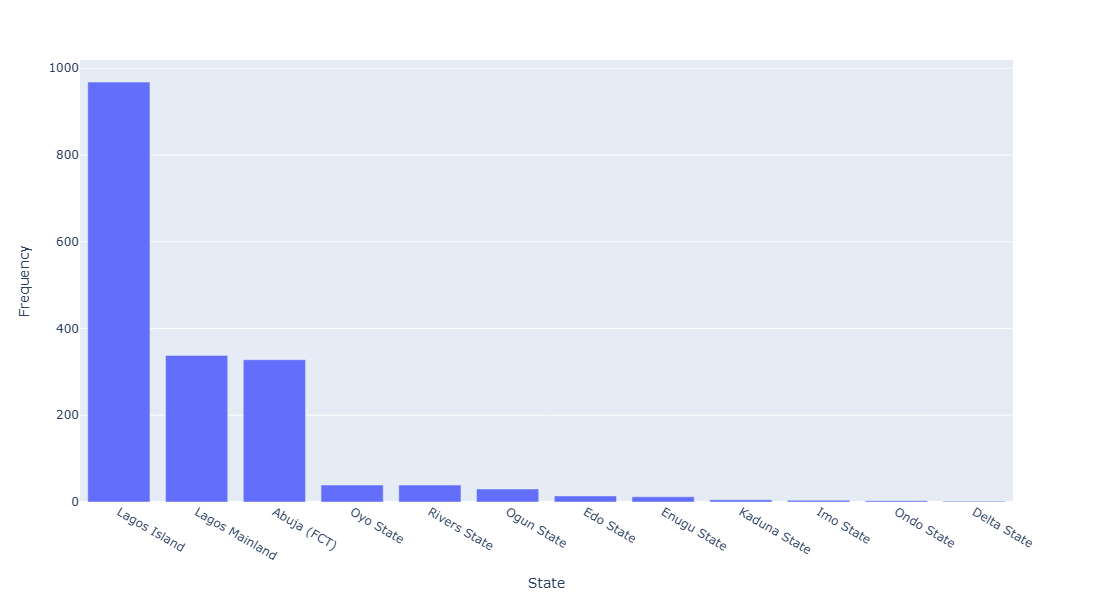

In [268]:
#bar chart for region count
region_count = df["region_parent_name"].value_counts()
fig1 = px.bar(
    x=region_count.index,
    y=region_count.values,
)
fig1.update_layout(
    xaxis_title='State',
    yaxis_title='Frequency',
    height=600
)
fig1.show()

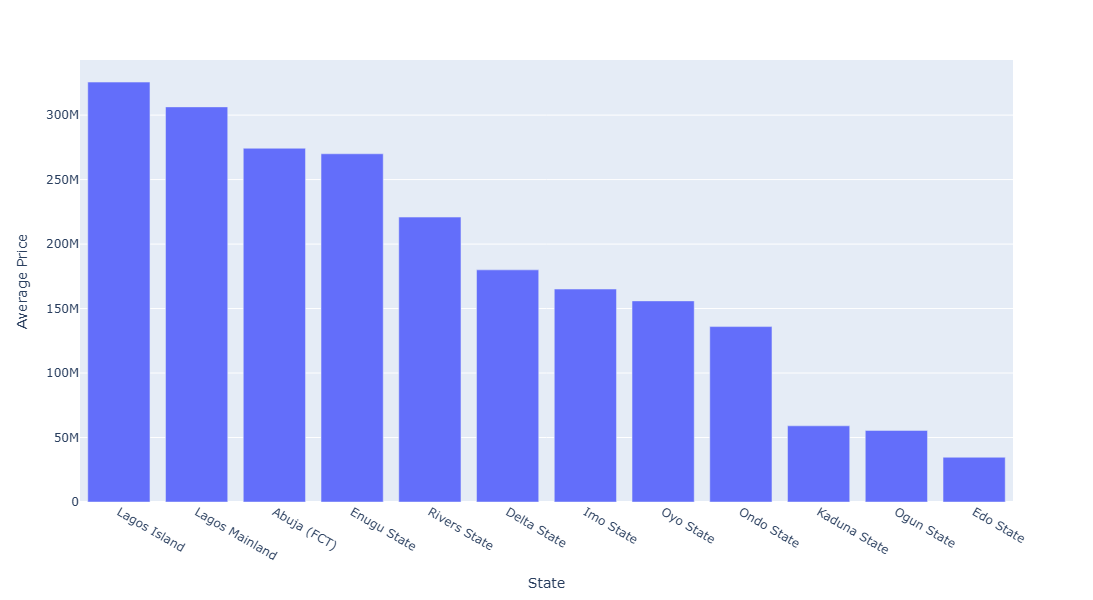

In [269]:
region_count = df.groupby("region_parent_name")["price"].mean().sort_values(ascending=False)
fig1 = px.bar(
    x=region_count.index,
    y=region_count.values,
)
fig1.update_layout(
    xaxis_title='State',
    yaxis_title='Average Price',
    height=600
)
fig1.show()

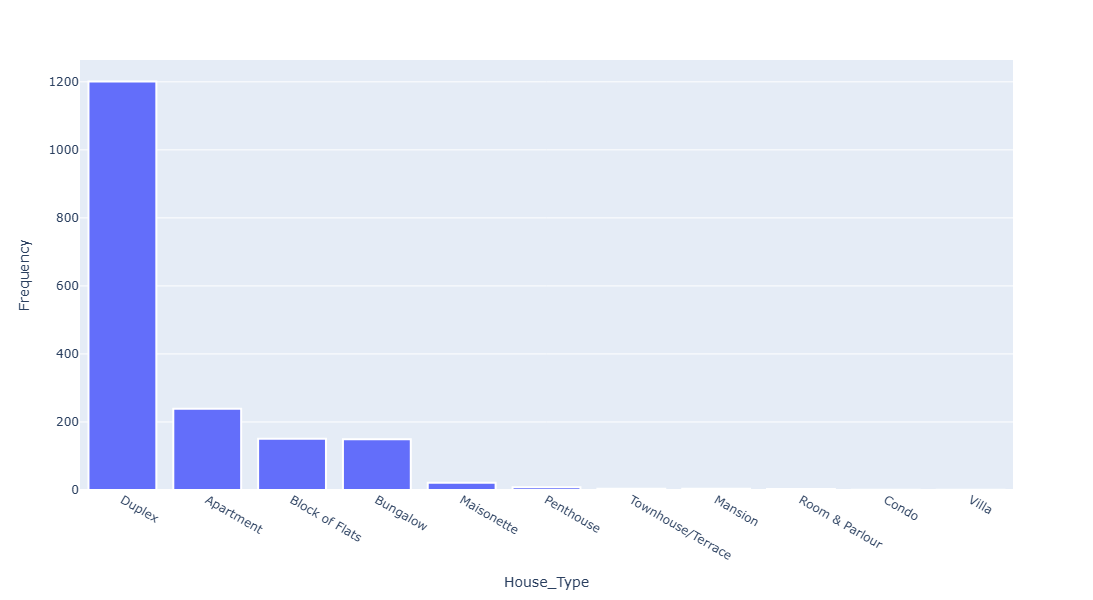

In [270]:
property_prices = df["house_type"].value_counts()
fig2 = px.histogram(
    x=property_prices.index,
    y=property_prices.values,
)
fig2.update_layout(
    xaxis_title='House_Type',
    yaxis_title='Frequency',
    height=600
)
fig2.update_traces(
marker_line_color="white",
marker_line_width=2
)
fig2.show()

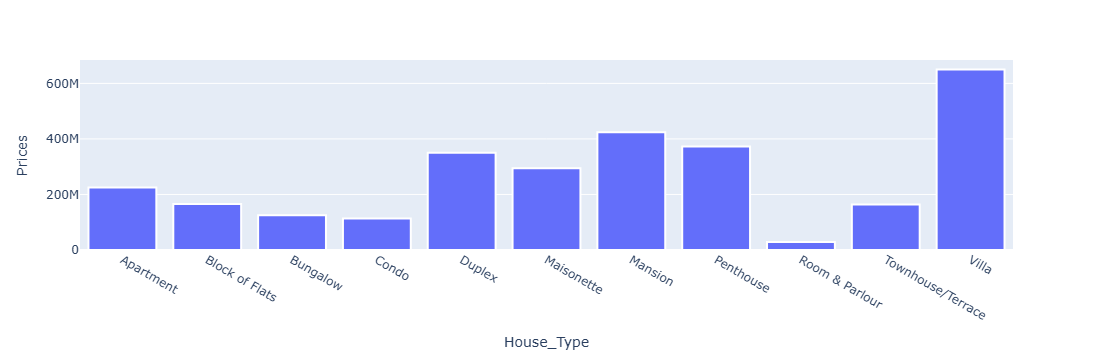

In [271]:
#histogram for house type by price
property_prices = df.groupby("house_type")['price'].mean()
fig2 = px.histogram(
    x=property_prices.index,
    y=property_prices.values,
)
fig2.update_layout(
    xaxis_title='House_Type',
    yaxis_title='Prices'
)
fig2.update_traces(
marker_line_color="white",
marker_line_width=2
)
fig2.show()

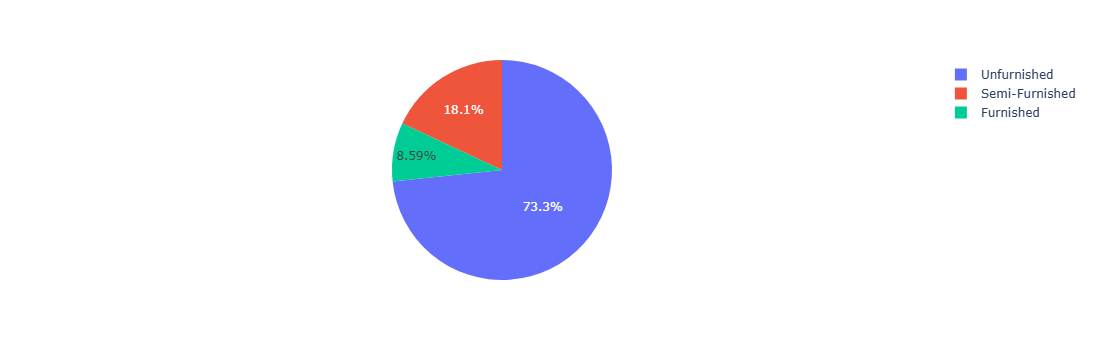

In [272]:
#pie chart 
furnish_count = df["furnishing"].value_counts()
fig3 = px.pie(
    values=furnish_count.values,
    names=furnish_count.index,
)
fig3.show()

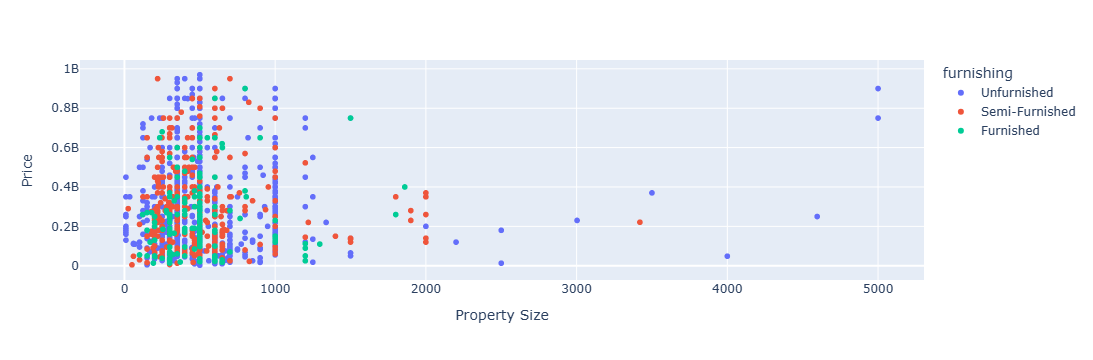

In [273]:
#scatter plot 
fig4 = px.scatter(
    df,
    x="property_size(sqm)",
    y="price",
    color="furnishing",
    labels={
        "property_size(sqm)": "Property Size",
        "price": "Price"
    }
)
fig4.show()

**Summary Report and Reccommendation**

**Key Findings**
* The highest-priced markets were concentrated in premium locations such as **Ikoyi, Garki 1, Victoria Island, Ilupeju, and Ogudu**, while lower averages appeared in **Ogun, Edo, Kaduna, Osun, Ibadan, and Ikorodu**.
* Furnished homes were not consistently more expensive: **semi-furnished listings** averaged **₦316.7M**, **unfurnished ₦298.0M**, while **furnished homes** averaged **₦241.4M**.
* Bedrooms and bathrooms have a **positive but relatively weak relationship** with price (correlations of **0.279** and **0.252** respectively), although **prices generally rise for larger 4–7 bedroom homes**.
* Enterprise listings were not typically the most expensive: they averaged ₦319.8M, compared with **₦600M for Basic listings** and **₦305M for VIP listings.**
* **Villas, mansions, penthouses, and duplexes** attracted the highest average prices, with **villas averaging about ₦650M** and **mansions ₦423.8M**.
* **Lagos** dominated the dataset and premium market, particularly **Lekki**, while **Abuja (FCT)** also recorded **high average prices** and substantial total listing value.
* Overall, **Lagos and Abuja** showed **stronger premium-market activity**, while many other regions had considerably lower average listing prices.

**Business-Focused Insight Summary**

Premium property types, such as **villas, mansions, penthouses and duplexes,** offer the **strongest pricing power**, making them important segments for sellers targeting higher-value transactions. **Lagos has the greatest revenue potential**, driven by its concentration of listings and high-value property markets; Abuja also represents a significant premium market.

Lower-priced regions outside Lagos and Abuja, including several northern and southwestern states, underperform in total revenue potential, largely because of lower average listing prices and/or smaller market activity.

Notably, the analysis file does not contain a **usable timestamp-based activity** analysis, so no specific period can be identified as having the highest listing activity.

**Recommendations**
* Sellers in weaker regions could improve performance through localized pricing, targeted digital promotion, better property photography, and partnerships with local agents.
* To increase visibility and pricing power, sellers should emphasize high-demand features, accurate property details, strong visuals, appropriate furnishing, and strategic listing promotion, rather than relying on Enterprise/boost status alone.
